# Cybersecurity — Malicious URL Detection: Multi-class Modeling

Continues from `01_eda_preprocessing`. **4-class** problem (benign / defacement / malware / phishing)
with moderate imbalance (benign ≈ 67%, malware ≈ 3.7%). We compare an unhandled baseline against the
same two imbalance strategies used in the fraud project, adapted for multi-class:

| Model | Imbalance strategy |
|---|---|
| **Baseline** | none |
| **Track A — SMOTE** | oversample the minority classes (train fold only) |
| **Track B — Cost-sensitive** | `class_weight='balanced'` — re-weights loss, no synthetic data |

**Metrics:** accuracy is misleading (guessing "benign" scores 67%), so we judge on **macro-F1** and
**per-class recall** — with special attention to recall on **malware** and **phishing**, the
security-critical classes we most need to catch. Prediction is `argmax` over classes (no single
threshold to tune, unlike the binary fraud task). Estimator: `HistGradientBoostingClassifier`.


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from collections import Counter
from urllib.parse import urlparse
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (f1_score, recall_score, accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')
CLASSES = ['benign', 'defacement', 'malware', 'phishing']
MC = {'Baseline': '#898781', 'Track A (SMOTE)': '#2a78d6', 'Track B (cost-sensitive)': '#1baf7a'}
DATA_PATH = '../../data/cybersecurity-malicious-urls/malicious_phish.csv'
RANDOM_STATE, TARGET = 42, 'type'

## 1. Reproduce features + split from notebook 01

In [2]:
SHORTENERS = {'bit.ly','tinyurl.com','goo.gl','t.co','ow.ly','is.gd','buff.ly','cutt.ly','rebrand.ly'}
SUSPICIOUS = r'login|secure|account|update|bank|verify|signin|confirm|password|free|webscr|paypal|ebayisapi'

def host_of(u):
    t = u if u.lower().startswith('http') else 'http://' + u
    try: return urlparse(t).netloc.split(':')[0]
    except ValueError: return t.split('://', 1)[-1].split('/', 1)[0].split('?', 1)[0].split(':')[0]

def path_of(u):
    t = u if u.lower().startswith('http') else 'http://' + u
    try: return urlparse(t).path or ''
    except ValueError:
        r = t.split('://', 1)[-1]; return '/' + r.split('/', 1)[1] if '/' in r else ''

def entropy(s):
    if not s: return 0.0
    n = len(s); c = Counter(s); return float(-sum((v/n) * np.log2(v/n) for v in c.values()))

df = pd.read_csv(DATA_PATH).drop_duplicates().reset_index(drop=True)
df['url'] = df['url'].str.strip()
bad = df.groupby('url')[TARGET].nunique()
df = df[~df['url'].isin(bad[bad > 1].index)].reset_index(drop=True)

s = df['url']; low = s.str.lower(); F = pd.DataFrame(index=df.index)
F['url_len']=s.str.len(); F['n_dots']=s.str.count(r'\.'); F['n_hyphen']=s.str.count('-')
F['n_digits']=s.str.count(r'\d'); F['n_slash']=s.str.count('/'); F['n_special']=s.str.count(r'[@?%=&_~+]')
host=s.map(host_of); F['host_len']=host.str.len(); F['path_len']=s.map(path_of).str.len()
F['n_subdomains']=host.str.count(r'\.')
F['digit_ratio']=(F['n_digits']/F['url_len']).fillna(0); F['url_entropy']=s.map(entropy)
F['has_https']=low.str.startswith('https').astype(int); F['has_at']=s.str.contains('@').astype(int)
F['has_ip']=host.str.contains(r'^(?:\d{1,3}\.){3}\d{1,3}$', regex=True).astype(int)
F['is_shortened']=host.str.lower().isin(SHORTENERS).astype(int)
F['has_suspicious']=low.str.contains(SUSPICIOUS, regex=True).astype(int)
F['scheme']=np.where(low.str.startswith('https'),'https', np.where(low.str.startswith('http'),'http','none'))
tld=host.str.rsplit('.', n=1).str[-1].str.lower().where(host.str.contains(r'\.'), 'none')
F['tld']=tld.where(tld.isin(tld.value_counts().head(15).index), 'other')
F[TARGET]=df[TARGET].values

X, y = F.drop(columns=[TARGET]), F[TARGET]
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test   = train_test_split(X_tmp, y_tmp, test_size=.50, stratify=y_tmp, random_state=RANDOM_STATE)
print('train/val/test:', len(X_train), len(X_val), len(X_test))
print('train class counts:', y_train.value_counts().to_dict())

train/val/test: 512890 64111 64112
train class counts: {'benign': 342459, 'defacement': 76246, 'phishing': 75269, 'malware': 18916}


Benign is ~67% of the data, so a model that only ever says *benign* would score 67% accuracy while
catching **zero** malware or phishing — this is exactly why we score on macro-F1 and per-class recall.

## 2. Preprocessor — fit **inside** each pipeline (train-only, leakage-safe)

In [3]:
log_cols = ['url_len','n_dots','n_hyphen','n_digits','n_slash','n_special','host_len','path_len','n_subdomains']
num_cols = ['digit_ratio','url_entropy']
bin_cols = ['has_https','has_at','has_ip','is_shortened','has_suspicious']
cat_cols = ['tld','scheme']

def make_pre():
    log_pipe = Pipeline([('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
                         ('scale', StandardScaler())])
    return ColumnTransformer([
        ('log', log_pipe, log_cols),
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('bin', 'passthrough', bin_cols)])

## 3. Fit the three models  *(takes ~2-3 min)*

In [4]:
# SMOTE (multi-class): oversample each minority class to a moderate target — NOT full balance,
# which would inflate the set to ~4x and add excess synthetic noise.
smote_strategy = {'defacement': 150000, 'phishing': 150000, 'malware': 100000}

models = {
    'Baseline': Pipeline([
        ('pre', make_pre()),
        ('clf', HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE))]),
    'Track B (cost-sensitive)': Pipeline([
        ('pre', make_pre()),
        ('clf', HistGradientBoostingClassifier(max_iter=200, class_weight='balanced', random_state=RANDOM_STATE))]),
    'Track A (SMOTE)': ImbPipeline([
        ('pre', make_pre()),
        ('smote', SMOTE(sampling_strategy=smote_strategy, k_neighbors=5, random_state=RANDOM_STATE)),
        ('clf', HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE))]),
}
for name, m in models.items():
    m.fit(X_train, y_train); print('fitted:', name)

fitted: Baseline


fitted: Track B (cost-sensitive)


fitted: Track A (SMOTE)


- **Track A** synthesizes minority URLs in feature space (train fold only) up to a capped target.
- **Track B** leaves the data untouched and instead weights each class inversely to its frequency —
  so a missed **malware** example costs ~18× a missed benign one.
- Multi-class prediction is `argmax` over the four class probabilities; there is no single threshold to tune.

## 4. Evaluate on the held-out test set

In [5]:
rows, preds = [], {}
for name, m in models.items():
    pred = m.predict(X_test); preds[name] = pred
    proba = m.predict_proba(X_test)
    rows.append({'model': name,
                 'accuracy': accuracy_score(y_test, pred),
                 'macro_F1': f1_score(y_test, pred, average='macro'),
                 'weighted_F1': f1_score(y_test, pred, average='weighted'),
                 'macro_recall': recall_score(y_test, pred, average='macro'),
                 'macro_ROC_AUC': roc_auc_score(y_test, proba, multi_class='ovr',
                                                average='macro', labels=m.classes_)})
results = pd.DataFrame(rows).set_index('model').round(4)
results

,accuracy,macro_F1,weighted_F1,macro_recall,macro_ROC_AUC
model,,,,,
Baseline,0.9470,0.9194,0.9461,0.9046,0.9908
Track B (cost-sensitive),0.9381,0.9201,0.9402,0.9390,0.9923
Track A (SMOTE),0.9519,0.9312,0.9521,0.9328,0.9926


In [6]:
# per-class recall (the security view) for every model
per_class = pd.DataFrame(
    {name: recall_score(y_test, preds[name], average=None, labels=CLASSES) for name in models},
    index=CLASSES).round(3)
print('Per-class RECALL:'); per_class

Per-class RECALL:


,Baseline,Track B (cost-sensitive),Track A (SMOTE)
benign,0.977,0.935,0.966
defacement,0.984,0.989,0.989
malware,0.862,0.930,0.919
phishing,0.796,0.902,0.857


In [7]:
best_name = results.drop(index='Baseline')['macro_F1'].idxmax()
print('Best macro-F1 (excl. baseline):', best_name, '\n')
print(classification_report(y_test, preds[best_name], labels=CLASSES, digits=3))

Best macro-F1 (excl. baseline): Track A (SMOTE) 



              precision    recall  f1-score   support

      benign      0.976     0.966     0.971     42808
  defacement      0.965     0.989     0.977      9531
     malware      0.941     0.919     0.930      2364
    phishing      0.837     0.857     0.847      9409

    accuracy                          0.952     64112
   macro avg      0.930     0.933     0.931     64112
weighted avg      0.952     0.952     0.952     64112



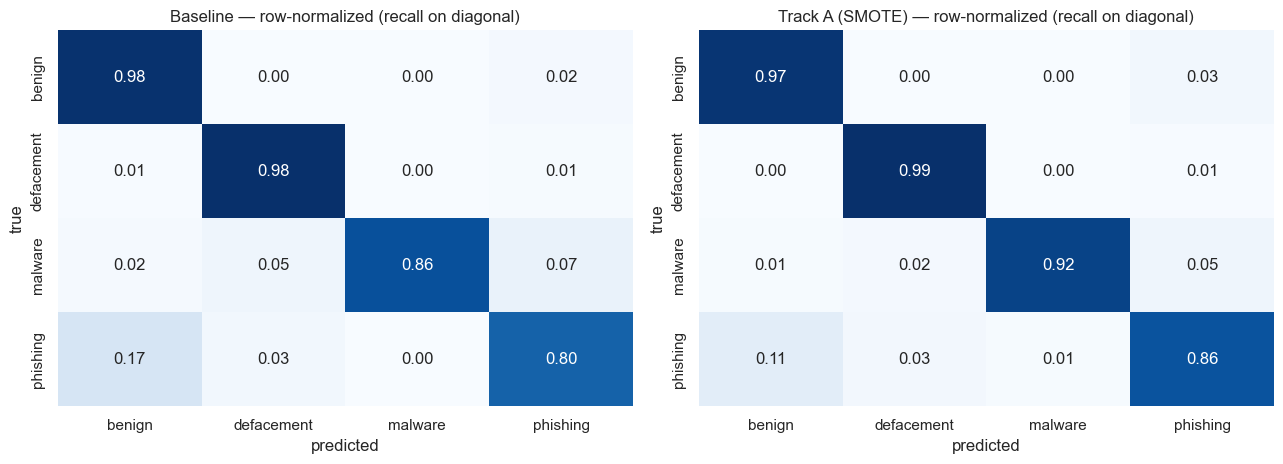

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
for a, name in zip(ax, ['Baseline', best_name]):
    cm = confusion_matrix(y_test, preds[name], labels=CLASSES, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False, ax=a,
                xticklabels=CLASSES, yticklabels=CLASSES)
    a.set_title('%s — row-normalized (recall on diagonal)' % name)
    a.set_xlabel('predicted'); a.set_ylabel('true')
plt.tight_layout(); plt.show()

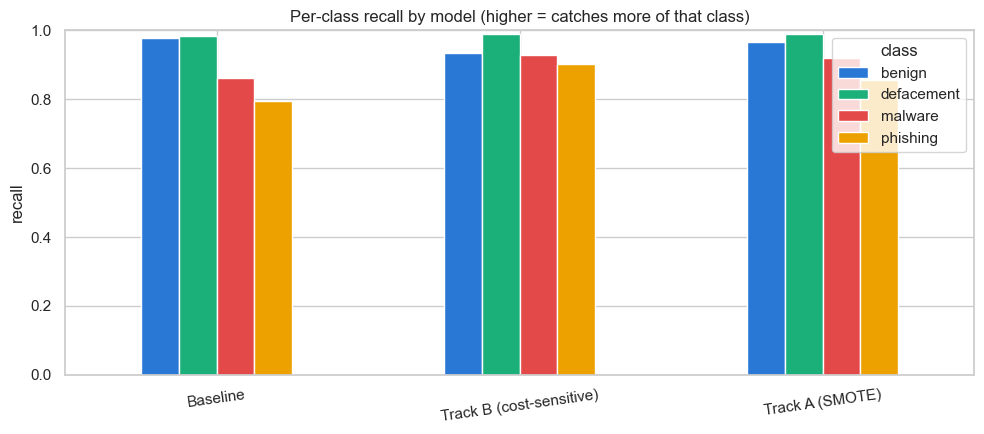

In [9]:
ax = per_class.T.plot.bar(figsize=(10, 4.5), color=['#2a78d6','#1baf7a','#e34948','#eda100'], rot=8)
ax.set_title('Per-class recall by model (higher = catches more of that class)')
ax.set_ylabel('recall'); ax.set_ylim(0, 1); ax.set_xlabel(''); ax.legend(title='class')
plt.tight_layout(); plt.show()

## 5. Explainability — permutation importance (macro-F1)

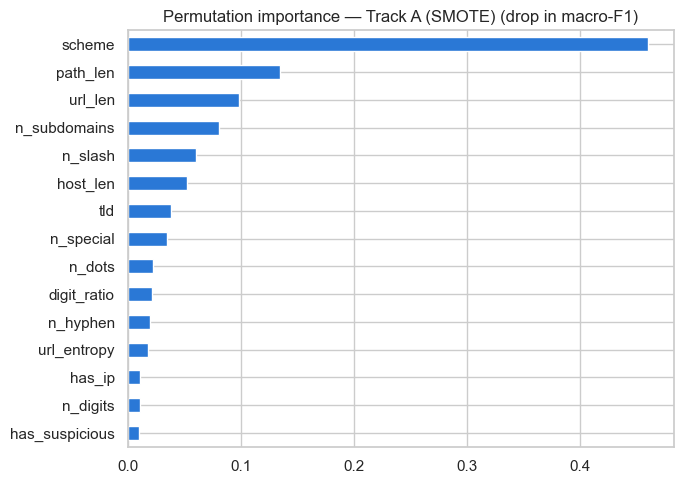

scheme            0.4598
path_len          0.1345
url_len           0.0982
n_subdomains      0.0806
n_slash           0.0602
host_len          0.0518
tld               0.0382
n_special         0.0345
n_dots            0.0221
digit_ratio       0.0208
n_hyphen          0.0195
url_entropy       0.0176
has_ip            0.0109
n_digits          0.0103
has_suspicious    0.0100
dtype: float64

In [10]:
best = models[best_name]
samp = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE)
ys = y_test.loc[samp.index]
pi = permutation_importance(best, samp, ys, scoring='f1_macro',
                            n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(7, 5)); imp.iloc[::-1].plot.barh(color='#2a78d6')
plt.title('Permutation importance — %s (drop in macro-F1)' % best_name); plt.tight_layout(); plt.show()
imp.round(4)

## 6. Summary & recommendation

**Test-set results** (4-class, prediction = argmax):

| Model | Accuracy | Macro-F1 | Macro-recall | Malware recall | Phishing recall |
|---|---|---|---|---|---|
| Baseline (no handling) | 0.947 | 0.919 | 0.905 | 0.862 | 0.796 |
| **Track B — cost-sensitive** | 0.938 | 0.920 | **0.939** | **0.930** | **0.902** |
| **Track A — SMOTE** | **0.952** | **0.931** | 0.933 | 0.919 | 0.857 |

- **Accuracy hides the real problem.** The baseline scores a healthy 94.7% accuracy yet **misses ~14% of malware and ~20% of phishing** — the two classes we most need to catch. This is the imbalance trap.
- **Both strategies fix the minority classes.** Track B (cost-sensitive) delivers the **best recall on malware (0.93) and phishing (0.90)** and the best macro-recall — it just costs a little benign recall / overall accuracy. Track A (SMOTE) has the best **macro-F1 (0.931)** and accuracy, but slightly lower recall on the dangerous classes.
- **Recommendation:** for a security URL filter, a **missed malware/phishing link is the expensive error**, so **Track B (cost-sensitive)** is the better default — it maximizes catch-rate on the dangerous classes with no synthetic data. Choose **Track A (SMOTE)** only if balanced overall precision/accuracy matters more than minority recall.
- **Hardest class: phishing** (recall ≤0.90, precision 0.84) — lexically it most resembles benign URLs.
- **Top drivers** (permutation importance): `scheme`, `path_len`, `url_len`, `n_subdomains`, `n_slash` — URL structure and host shape carry most of the signal, consistent with the EDA (defacement = long deep paths; malware = IP hosts).
- **Next steps:** add character **n-gram / TF-IDF** token features and domain-age/WHOIS signals to lift phishing recall; per-class threshold calibration from a cost matrix; try `BalancedRandomForest` / `ADASYN` as challengers.